In [1]:
import os
from torchvision import transforms
import torch

IMAGE_FORMAT = ["jpeg", "jpg", "png"]

def list_image_files(data_dir, sub_dir):
    classes = data_dir.split('/')[-1]
    image_files = []
    images_dir = os.path.join(data_dir, sub_dir)
    for file_path in os.listdir(images_dir):
        if file_path.split(".")[-1] in IMAGE_FORMAT:
            image_files.append(os.path.join(classes, sub_dir, file_path))
    return image_files


transformer = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                            std=[0.229, 0.224, 0.225])
])
transformer

Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

In [2]:
list_image_files('./new_data/','under/')
list_image_files('./new_data/','over/')
temp = list_image_files('./new_data/','normal/')

In [3]:
temp[0].split('/')

['normal', '221201_155254_0000000016_CAM1_NORMAL_OK.jpg']

In [4]:
class_to_label = {'normal' : 0, 'over' : 1, 'under' : 2}
label_to_class = {0 : 'normal', 1 : 'over', 2 : 'under'}

In [5]:
from PIL import Image
class Cooper_dataset():
    def __init__(self, data_dir, transformer = None):
        self.data_dir = data_dir
        norm_list = list_image_files(self.data_dir, 'normal/')
        over_list = list_image_files(self.data_dir, 'over/')
        under_list = list_image_files(self.data_dir, 'under/')
        
        self.path_list = norm_list + over_list + under_list
        
        self.transformer = transformer
        
    def __len__(self):
        return len(self.path_list)

    def __getitem__(self, index):
        image_path = os.path.join(self.data_dir, self.path_list[index])
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = Image.fromarray(image) 
        class_name = self.path_list[index].split('/')[0]
        class_id = class_to_label[class_name]

        if self.transformer:
            image = self.transformer(image)
            class_id = torch.Tensor([class_id]).long()
        return image, class_id, image_path

In [6]:
dataset = Cooper_dataset('./new_data/', transformer = transformer)

In [7]:
from torch.utils.data import DataLoader

In [8]:
d_loader = DataLoader(dataset, shuffle = False, drop_last = False, batch_size = 1)

In [9]:
import numpy as np
import cv2
for image, label, path in d_loader:
    break

In [10]:
image = np.transpose(image[0],(1,2,0))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Text(0.5, 1.0, "normal ('./new_data/normal/221201_155254_0000000016_CAM1_NORMAL_OK.jpg',)")

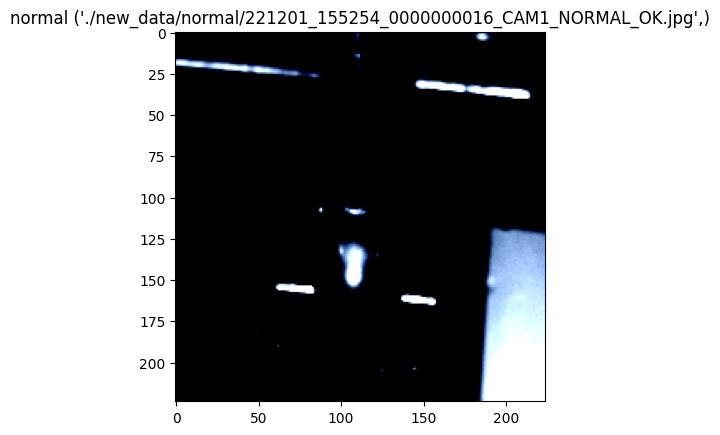

In [11]:
import matplotlib.pyplot as plt

plt.imshow(image)
plt.title(f'{label_to_class[label.item()]} {path}')

In [12]:
%pwd

'C:\\Users\\user\\paper_cnn_0704'

In [14]:
import timm
device = 'cuda'
num_classes = 3
model = timm.create_model('resnet50', pretrained = True, num_classes = num_classes).to(device)

In [15]:
model.load_state_dict(torch.load('./models/pretrained_all_resnet_pretrained_True_shuffle_false_optim_AdamW_lr_0.001.pt'))

<All keys matched successfully>

In [16]:
path[0]

'./new_data/normal/221201_155254_0000000016_CAM1_NORMAL_OK.jpg'

In [17]:
from tqdm.notebook import tqdm
label_lst = []
pred_lst = []
path_lst = []
with torch.no_grad():
    model.eval()
    for image, class_id, path in tqdm(d_loader):
        image = image.to(device)
        label = class_id
        path = path[0]
        pred = model(image).max(1, keepdim = True)[1].detach().to('cpu').numpy().reshape(-1)
        label_lst.append(label)
        pred_lst.append(pred)
        path_lst.append(path)

  0%|          | 0/31013 [00:00<?, ?it/s]

In [18]:
class_to_label = {'normal' : 0, 'over' : 1, 'under' : 2}

In [19]:
norm_to_over = []
norm_to_under = []

over_to_norm = []
over_to_under = []

under_to_norm = []
under_to_over = []

for i in tqdm(range(len(path_lst))):
    label = label_lst[i]
    pred = pred_lst[i]
    path = path_lst[i]
    
    if label == 0:
        if pred == 1:
            norm_to_over.append(path)
        elif pred == 2:
            norm_to_under.append(path)
    elif label == 1:
        if pred == 0:
            over_to_norm.append(path)
        elif pred == 2:
            over_to_under.append(path)
    elif label == 2:
        if pred == 0:
            under_to_norm.append(path)
        elif pred == 1:
            under_to_over.append(path)

  0%|          | 0/31013 [00:00<?, ?it/s]

In [20]:
from sklearn.metrics import confusion_matrix

In [21]:
label_lst2 = []
for label in label_lst:
    label_lst2.append(label.numpy().reshape(-1))

In [22]:
label_lst2

[array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], 

In [23]:
pred_lst

[array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], dtype=int64),
 array([0], 

In [24]:
confusion_matrix(label_lst2, pred_lst)

array([[29732,    41,    41],
       [   75,   491,     1],
       [   69,     2,   561]], dtype=int64)

In [32]:
len(norm_to_over), len(norm_to_under)

(41, 41)

In [29]:
len(over_to_norm), len(over_to_under)

(75, 1)

In [30]:
len(under_to_norm), len(under_to_over)

(69, 2)

In [25]:
import shutil
def image_shutils(path_lst, label, pred):
    for i in range(len(path_lst)):
        origin_path = path_lst[i]
        change_path = f'./hard_image/{label}_{pred}/' + path_lst[i].split('/')[-1]
        shutil.move(origin_path, change_path)

In [26]:
image_shutils(norm_to_over, 'norm', 'over')

In [27]:
image_shutils(norm_to_under, 'norm', 'under')

In [28]:
image_shutils(over_to_norm, 'over', 'norm')

In [29]:
image_shutils(over_to_under, 'over', 'under')

In [30]:
image_shutils(under_to_norm, 'under', 'norm')

In [31]:
image_shutils(under_to_over, 'under', 'over')